In [3]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [4]:
filename = "data/preprocessed_combined_p.xlsx" # removed an outlier row which had value 196 for p

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)

spectral_data = df.iloc[:, 3:436]
output_variable = df.iloc[:, 439:440]


In [14]:
spectral_data.head()
output_variable.head()

,P
0,29
1,17
2,16
3,49
4,53


In [15]:
print(spectral_data.shape)
print(output_variable.shape)

(150, 433)
(150, 1)


In [16]:
output_variable.describe()

,P
count,150.000000
mean,21.453333
std,21.206428
min,0.000000
25%,6.000000
50%,13.000000
75%,30.750000
max,108.000000


Text(0.5, 1.0, 'Output P Distribution')

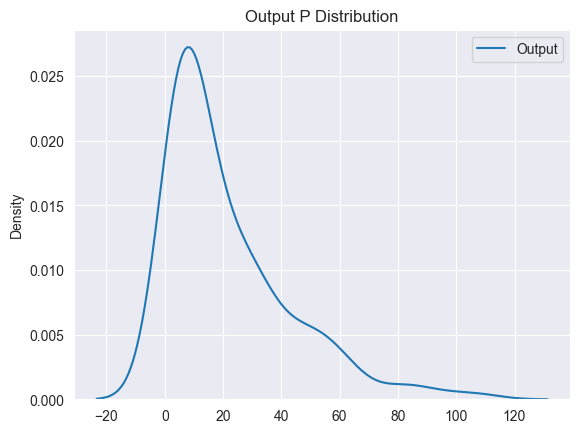

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output P Distribution")

In [5]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
#
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [20]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

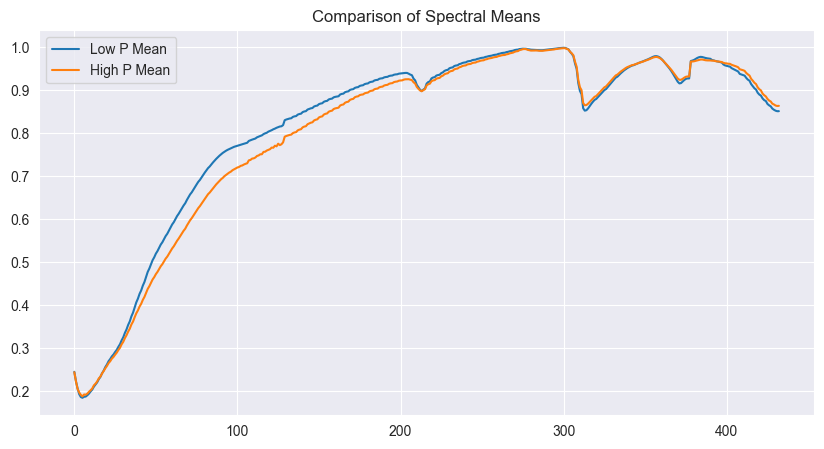

In [8]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low P Mean')
plt.plot(np.mean(high_n, axis=0), label='High P Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [31]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)


pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [32]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [33]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.4116
LOOCV RMSE: 16.2127


Train/Test split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [35]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667
22,0.242061,0.191091,0.160178,0.173841,0.173748,0.154688,0.167228,0.163204,0.159274,0.170940,...,0.875413,0.875580,0.867178,0.863976,0.860357,0.853952,0.855657,0.853786,0.847672,0.843055
15,0.298305,0.278024,0.240642,0.242954,0.240277,0.219859,0.235702,0.231906,0.232636,0.240496,...,0.916200,0.911625,0.913020,0.911625,0.907699,0.906206,0.897639,0.905103,0.900949,0.901176
65,0.294486,0.248949,0.232765,0.218048,0.205236,0.206664,0.211583,0.205514,0.215351,0.219119,...,0.776570,0.772022,0.763083,0.757530,0.755785,0.747322,0.743462,0.739072,0.737697,0.737961
11,0.311849,0.219691,0.209301,0.232581,0.195688,0.199022,0.216524,0.203912,0.209746,0.221830,...,0.877542,0.873949,0.873393,0.867874,0.860651,0.861022,0.852021,0.859836,0.855873,0.854243
42,0.223714,0.208908,0.189445,0.175717,0.172087,0.169890,0.174863,0.175320,0.178920,0.184015,...,0.925727,0.924954,0.917714,0.917145,0.914013,0.911450,0.908969,0.906650,0.907749,0.907098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.912659,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058
106,0.182750,0.164332,0.159684,0.145615,0.143632,0.143384,0.143694,0.144376,0.148280,0.149427,...,0.886561,0.883752,0.873546,0.871522,0.869042,0.861068,0.858300,0.856069,0.853466,0.853176
14,0.361333,0.235588,0.205330,0.252762,0.213328,0.206740,0.236767,0.214160,0.221927,0.240118,...,0.932674,0.924815,0.927958,0.922103,0.919514,0.914644,0.913165,0.914428,0.914428,0.911994
92,0.283301,0.251802,0.214142,0.216621,0.204456,0.194305,0.199496,0.202363,0.200814,0.208408,...,0.846907,0.847423,0.841689,0.838176,0.834922,0.830686,0.830531,0.826450,0.821697,0.819682


In [36]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [42]:


# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', PLSRegression(n_components=10))
])

In [43]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

Best R2: 0.06434516618057814


In [44]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.7755858712300028
RMSE: 16.2127


Feature selection using lasso

In [48]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.05)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


In [49]:
X_train_selected

array([[0.62421237, 0.80092333, 0.85594859, 0.9675796 , 0.91305342,
        0.90182378],
       [0.70365052, 0.80371867, 0.89488116, 0.97911901, 0.94232173,
        0.93459885],
       [0.79182864, 0.88904403, 0.77651726, 0.92820309, 0.81100093,
        0.79529287],
       [0.7216913 , 0.81057895, 0.85746564, 0.95669889, 0.90591547,
        0.89246953],
       [0.71891397, 0.80900549, 0.89367501, 0.99581045, 0.94325808,
        0.93605857],
       [0.74372208, 0.83361101, 0.87234899, 0.98595517, 0.92064067,
        0.90756167],
       [0.61276052, 0.76665356, 0.8850876 , 0.99545594, 0.94560231,
        0.93856775],
       [0.68672943, 0.77877158, 0.86576253, 0.95591422, 0.9172084 ,
        0.90331017],
       [0.76908246, 0.86452033, 0.86355401, 0.96724739, 0.91648471,
        0.90601626],
       [0.44477102, 0.66099585, 0.87067773, 0.96042723, 0.90312996,
        0.89319195],
       [0.60106755, 0.7761516 , 0.86386063, 1.        , 0.93027114,
        0.92101471],
       [0.49320074, 0

In [53]:

pls = PLSRegression(n_components=6)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.27890412855544755
RMSE: 16.521974743993074


Feature Importance from RF

In [64]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=8)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.7018001390390329
RMSE: 10.624760955703765


In [56]:
X_train_selected_rf

array([[0.24206126, 0.19109115, 0.17384116, ..., 0.85395221, 0.85378585,
        0.84767193],
       [0.29830453, 0.27802385, 0.24295449, ..., 0.90620589, 0.90510262,
        0.90094914],
       [0.29448631, 0.24894883, 0.21804839, ..., 0.74732249, 0.7390718 ,
        0.73769668],
       ...,
       [0.36133327, 0.23558781, 0.25276224, ..., 0.91464411, 0.91442837,
        0.91442837],
       [0.28330105, 0.25180163, 0.21662146, ..., 0.83068578, 0.8264497 ,
        0.82169702],
       [0.19403015, 0.18609987, 0.15397621, ..., 0.83956283, 0.8323974 ,
        0.83074694]])

In [60]:
mask = selector_rf.get_support()

selected_columns = X_train.columns[mask]

# 3. View the results
print(f"Number of features selected: {len(selected_columns)}")
print("Selected columns (wavelengths):")
print(selected_columns)

Number of features selected: 217
Selected columns (wavelengths):
Index(['349.866666666667', '354.95', '365.15', '375.325', '379.7', '384.075',
       '389.9', '404.45', '434.95', '465.25',
       ...
       '2429.7', '2434.03333333333', '2452.13333333333', '2464.26666666667',
       '2467.13333333333', '2479.2', '2482.06666666667', '2489.8', '2500.3',
       '2504.5'],
      dtype='object', length=217)


RF with GridSearchCV

In [57]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: -0.40972009365793827


In [58]:
best_rf = grid.best_estimator_

In [59]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: 0.5546893399158899
Test MSE: 168.5753191125738
